In [1]:
!pip install Keras
!pip install vit-keras
!pip install tensorflow-addons
!pip install opendatasets
!pip install tensorflow-hub

import opendatasets as od
import pandas

import os

import keras.preprocessing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras

from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from keras import layers
from keras import regularizers, activations
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense, Dropout, Flatten, Activation, Concatenate, Lambda #....
from keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, ZeroPadding2D #....
from keras.models import Model
from keras.optimizers import Adam
from keras.applications import ResNet50V2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 31.2 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.1
    Uninstalling typeguard-4.4.1:
      Successfully uninstalled typeguard-4.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.4.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

!unzip "/content/drive/MyDrive/rembg.zip"

Streaming output truncated to the last 5000 lines.
  inflating: rembg/eosinophil/EO_546748.jpg  
  inflating: rembg/eosinophil/EO_800344.jpg  
  inflating: rembg/eosinophil/EO_606347.jpg  
  inflating: rembg/eosinophil/EO_882366.jpg  
  inflating: rembg/eosinophil/EO_828655.jpg  
  inflating: rembg/eosinophil/EO_211090.jpg  
  inflating: rembg/eosinophil/EO_650226.jpg  
  inflating: rembg/eosinophil/EO_23466371.jpg  
  inflating: rembg/eosinophil/EO_29954.jpg  
  inflating: rembg/eosinophil/EO_280451.jpg  
  inflating: rembg/eosinophil/EO_739061.jpg  
  inflating: rembg/eosinophil/EO_64440.jpg  
  inflating: rembg/eosinophil/EO_688063.jpg  
  inflating: rembg/eosinophil/EO_16004.jpg  
  inflating: rembg/eosinophil/EO_242314.jpg  
  inflating: rembg/eosinophil/EO_454841.jpg  
  inflating: rembg/eosinophil/EO_743865.jpg  
  inflating: rembg/eosinophil/EO_95563.jpg  
  inflating: rembg/eosinophil/EO_20674.jpg  
  inflating: rembg/eosinophil/EO_392948.jpg  
  inflating: rembg/eosinophil/EO

In [4]:
base_dir = "/content/rembg"

In [5]:
# prompt: image counts of each folders and subfolders

import os

def count_images(root_directory):
  """
  Counts the number of images in a directory and its subdirectories.

  Args:
    root_directory: The root directory to count images in.

  Returns:
    A dictionary where the keys are the subdirectories and the values are the number of images in each subdirectory.
  """

  image_counts = {}

  for subdirectory in os.listdir(root_directory):
    subdirectory_path = os.path.join(root_directory, subdirectory)

    if os.path.isdir(subdirectory_path):
      image_count = 0

      for file_name in os.listdir(subdirectory_path):
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
          image_count += 1

      image_counts[subdirectory] = image_count

  return image_counts

# Example usage
root_directory = base_dir
image_counts = count_images(root_directory)

for subdirectory, count in image_counts.items():
  print(f"Subdirectory: {subdirectory}, Image count: {count}")


Subdirectory: platelet, Image count: 2348
Subdirectory: monocyte, Image count: 1420
Subdirectory: basophil, Image count: 1218
Subdirectory: neutrophil, Image count: 3329
Subdirectory: lymphocyte, Image count: 1214
Subdirectory: ig, Image count: 2895
Subdirectory: eosinophil, Image count: 3117
Subdirectory: erythroblast, Image count: 1551


In [6]:
import os

def get_folder_names(directory_path):
    # Initialize an empty list to store folder names
    folder_names = []

    # Iterate over items in the specified directory
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)

        # Check if the item is a directory
        if os.path.isdir(item_path):
          if item != '.ipynb_checkpoints':
            folder_names.append(item)

    return folder_names

# Specify the directory path for which you want to fetch folder names
directory_path = base_dir

# Call the function to get folder names in the specified directory
folders = get_folder_names(directory_path)

# Print the list of folder names
print("Folder Names:", folders)


Folder Names: ['platelet', 'monocyte', 'basophil', 'neutrophil', 'lymphocyte', 'ig', 'eosinophil', 'erythroblast']


In [7]:
len(folders)

8

In [8]:
# prompt: show image height and width

# Assuming 'image_path' is the path to your image
image_path = '/content/rembg/basophil/BA_100102.jpg'  # Replace with the actual path
img = image.load_img(image_path)
width, height = img.size
print("Image Width:", width)
print("Image Height:", height)


Image Width: 224
Image Height: 224


In [9]:
import numpy as np
import sys
import os
import random
from tqdm import tqdm
from PIL import Image
import imgaug.augmenters as iaa

# Monkey-patch numpy to use np.bool_
sys.modules['numpy'].bool = np.bool_

def augment_image(image, augmenter):
    image_np = np.array(image)
    augmented_image_np = augmenter(image=image_np)
    augmented_image = Image.fromarray(augmented_image_np)

    # Convert to RGB if the mode is RGBA or has an alpha channel
    if augmented_image.mode == 'RGBA':
        augmented_image = augmented_image.convert('RGB')

    return augmented_image

def augment_images(source_directory, output_directory, target_count):
    # Define the augmentation pipeline using imgaug
    augmenter = iaa.Sequential([
        iaa.SomeOf((1, 4), [
            iaa.Fliplr(0.5),  # horizontal flips
            iaa.Affine(rotate=(-10, 10)),  # rotations
            iaa.Affine(scale=(0.8, 1.2)),  # zoom
            iaa.Affine(translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)}),  # translations
            iaa.AdditiveGaussianNoise(scale=(10, 20)),  # Gaussian noise
            iaa.Multiply((0.8, 1.2)),  # brightness
            iaa.LinearContrast((0.8, 1.2))  # contrast
        ])
    ])

    # Ensure the destination directory exists; create it if necessary
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    # Get the list of files in the source directory
    image_files = [f for f in os.listdir(source_directory) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))]

    # Calculate the number of additional images needed
    existing_images = len(image_files)
    images_per_original = max(1, target_count // existing_images)

    # Augment images until the target count is reached
    for filename in tqdm(image_files, desc=f"Augmenting images in {source_directory}"):
        img_path = os.path.join(source_directory, filename)
        img = Image.open(img_path)

        # Convert to RGB if the mode is RGBA
        if img.mode == 'RGBA':
            img = img.convert('RGB')

        # Save the original image to the output directory
        img.save(os.path.join(output_directory, f'orig_{filename}'))

        # Generate augmented images
        for i in range(images_per_original):
            augmented_image = augment_image(img, augmenter)
            augmented_image.save(os.path.join(output_directory, f'aug_{i}_{filename}'))

    # Remove excess images from the output directory
    output_images = os.listdir(output_directory)
    if len(output_images) > target_count:
        for i in range(len(output_images) - target_count):
            os.remove(os.path.join(output_directory, output_images[i]))

    print(f"Augmentation complete for {source_directory}. Total images in '{output_directory}': {len(os.listdir(output_directory))}")

# Specify the root directory containing subfolders
root_directory = base_dir  # Change this to your actual base directory

# Find the maximum number of images in any class
max_images = 3500
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        num_images = len([f for f in os.listdir(subfolder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))])
        if num_images > max_images:
            max_images = num_images

# Iterate through subfolders and augment images to match the maximum count
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        # Define source and output directories for the current subfolder
        source_directory = subfolder_path
        output_directory = os.path.join('/content/augmented', subfolder)

        # Call the augment_images function for the current subfolder
        augment_images(source_directory, output_directory, target_count=max_images)


Augmenting images in /content/rembg/platelet: 100%|██████████| 2348/2348 [00:13<00:00, 167.92it/s]


Augmentation complete for /content/rembg/platelet. Total images in '/content/augmented/platelet': 3500


Augmenting images in /content/rembg/monocyte: 100%|██████████| 1420/1420 [00:12<00:00, 113.51it/s]


Augmentation complete for /content/rembg/monocyte. Total images in '/content/augmented/monocyte': 3500


Augmenting images in /content/rembg/basophil: 100%|██████████| 1218/1218 [00:09<00:00, 130.42it/s]


...

Augmentation complete for /content/rembg/ig. Total images in '/content/augmented/ig': 3500


Augmenting images in /content/rembg/eosinophil: 100%|██████████| 3117/3117 [00:19<00:00, 159.28it/s]


Augmentation complete for /content/rembg/eosinophil. Total images in '/content/augmented/eosinophil': 3500


Augmenting images in /content/rembg/erythroblast: 100%|██████████| 1551/1551 [00:12<00:00, 119.65it/s]


Augmentation complete for /content/rembg/erythroblast. Total images in '/content/augmented/erythroblast': 3500


In [10]:
base_dir="/content/augmented"

In [11]:
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

val_dir = os.path.join(base_dir, 'val')
os.makedirs(val_dir, exist_ok=True)

test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

In [12]:

import shutil

# List of class folder names
class_folders = folders
# Split ratios (adjust these as needed)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for folder in class_folders:
    source_folder = os.path.join(base_dir, folder)
    train_dest = os.path.join(train_dir, folder)
    val_dest = os.path.join(val_dir, folder)
    test_dest = os.path.join(test_dir, folder)

    os.makedirs(train_dest, exist_ok=True)
    os.makedirs(val_dest, exist_ok=True)
    os.makedirs(test_dest, exist_ok=True)

    filenames = os.listdir(source_folder)
    num_files = len(filenames)

    num_train = int(num_files * train_ratio)
    num_val = int(num_files * val_ratio)

    train_files = filenames[:num_train]
    val_files = filenames[num_train:num_train + num_val]
    test_files = filenames[num_train + num_val:]

    for file in train_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(train_dest, file)
        shutil.copy(src_path, dest_path)

    for file in val_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(val_dest, file)
        shutil.copy(src_path, dest_path)

    for file in test_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(test_dest, file)
        shutil.copy(src_path, dest_path)



In [13]:

size = 224

batch_size = 64
target_size = (size,size)  # Adjust as needed

train_datagen = ImageDataGenerator(
    rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size)

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

Found 19600 images belonging to 8 classes.
Found 4200 images belonging to 8 classes.
Found 4200 images belonging to 8 classes.


In [14]:
test_labels = np.array(test_generator.labels)

In [18]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.models import Model
from tensorflow.keras.applications import NASNetMobile, InceptionResNetV2

# Custom GroupNormalization layer
class GroupNormalization(layers.Layer):
    def __init__(self, groups=32, **kwargs):
        super(GroupNormalization, self).__init__(**kwargs)
        self.groups = groups

    def build(self, input_shape):
        self.scale = self.add_weight(name='scale', shape=(input_shape[-1],),
                                     initializer='ones', trainable=True)
        self.offset = self.add_weight(name='offset', shape=(input_shape[-1],),
                                      initializer='zeros', trainable=True)

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        group_shape = tf.concat([input_shape[:-1], [self.groups, input_shape[-1] // self.groups]], axis=0)
        grouped_inputs = tf.reshape(inputs, group_shape)
        mean, variance = tf.nn.moments(grouped_inputs, [1, 2], keepdims=True)
        normalized_inputs = (grouped_inputs - mean) / tf.sqrt(variance + 1e-5)
        normalized_inputs = tf.reshape(normalized_inputs, input_shape)
        return normalized_inputs * self.scale + self.offset

# Define the model creation function
def create_NASNetMobile_InceptionResNetV2_model(input_shape, num_classes):
    # Load pre-trained NASNetMobile and InceptionResNetV2 models
    NASNetMobile_model = NASNetMobile(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))
    InceptionResNetV2_model = InceptionResNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))

    # Freeze the pre-trained models
    NASNetMobile_model.trainable = False
    InceptionResNetV2_model.trainable = False

    # Input layer
    input_layer = Input(shape=input_shape)

    # Extract features from both models
    NASNetMobile_features = NASNetMobile_model(input_layer)
    InceptionResNetV2_features = InceptionResNetV2_model(input_layer)

    # Global average pooling for features
    NASNetMobile_pooled = layers.GlobalAveragePooling2D()(NASNetMobile_features)
    InceptionResNetV2_pooled = layers.GlobalAveragePooling2D()(InceptionResNetV2_features)

    # Concatenate features
    combined_features = layers.Concatenate()([NASNetMobile_pooled, InceptionResNetV2_pooled])

    # Add Dense and Dropout layers
    x = Flatten()(combined_features)
    x = layers.BatchNormalization()(x)
    x = Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.BatchNormalization()(x)
    x = Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.BatchNormalization()(x)
    x = Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)
    output_layer = Dense(num_classes, activation='softmax')(x)

    # Build the model
    model = Model(inputs=input_layer, outputs=output_layer)

    return model

# Define the input shape and number of classes
input_shape = (224, 224, 3)  # Example input shape, adjust as needed
num_classes = 8  # Example number of classes, adjust as needed

# Create the model
model = create_NASNetMobile_InceptionResNetV2_model(input_shape, num_classes)

# Print the model summary
model.summary()


19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ nasnet_mobile             │ (None, 7, 7, 1056)     │      4,269,716 │ input_layer_8[0][0]    │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ inception_resnet_v2       │ (None, 5, 5, 1536)     │     54,336,736 │ input_layer_8[0][0]    │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 1056)           │              0 │ nasnet_mobile[0][0]    │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 1536)           │              0 │ inception_resnet_v2[0… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_10            │ (None, 2592)           │              0 │ global_average_poolin… │
│ (Concatenate)             │                        │                │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_2 (Flatten)       │ (None, 2592)           │              0 │ concatenate_10[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_393   │ (None, 2592)           │         10,368 │ flatten_2[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 128)            │        331,904 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 128)            │              0 │ dense_8[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_394   │ (None, 128)            │            512 │ dropout_4[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_9 (Dense)           │ (None, 128)            │         16,512 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_5 (Dropout)       │ (None, 128)            │              0 │ dense_9[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_395   │ (None, 128)            │            512 │ dropout_5[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_10 (Dense)          │ (None, 128)            │         16,512 │ batch_normalization_3… │
├──────────────────────

 Total params: 58,984,316 (225.01 MB)

 Trainable params: 371,912 (1.42 MB)

 Non-trainable params: 58,612,404 (223.59 MB)

In [19]:
input_shape = (224, 224, 3)  # Input image shape
num_classes = 8  # Number of output classes


model = create_NASNetMobile_InceptionResNetV2_model(input_shape, num_classes)

# optim = keras.optimizers.AdamW(
#     learning_rate=0.0001,
#     weight_decay=0.006,
#     beta_1=0.9,
#     beta_2=0.999,
#     epsilon=1e-07,
#     amsgrad=True,
#     clipnorm=None,
#     clipvalue=None,
#     global_clipnorm=None,
#     use_ema=True,
#     ema_momentum=0.99,
#     ema_overwrite_frequency=None,
#     name="adamw"
# )


# from keras.optimizers import Nadam

# optim = Nadam(
#     learning_rate=0.0001,
#     beta_1=0.9,
#     beta_2=0.999,
#     epsilon=1e-07,
#     weight_decay=0.006,
#     clipnorm=None,
#     clipvalue=None,
#     global_clipnorm=None,
#     use_ema=False,
#     ema_momentum=0.99,
#     ema_overwrite_frequency=None,
#     name="nadam"
# )

def weighted_categorical_crossentropy(weights):
    """
    Weighted categorical crossentropy for multi-class classification.

    Args:
        weights (list or array): A list or array with 4 elements for the weights of each class.

    Returns:
        loss (function): A function that computes the weighted categorical crossentropy loss.
    """
    def loss(y_true, y_pred):
        # Clip predictions to prevent NaN errors
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1 - tf.keras.backend.epsilon())

        # Calculate unweighted categorical crossentropy
        unweighted_loss = y_true * tf.math.log(y_pred)

        # Multiply by class weights
        weighted_loss = unweighted_loss * tf.constant(weights, dtype=tf.float32)

        # Sum the loss for each class and take the mean
        return -tf.reduce_mean(tf.reduce_sum(weighted_loss, axis=-1))

    return loss

weights = [0.5, 0.7, 1.0, 1.2, 1.5, 1.7, 2.0, 2.5]

#weighted_categorical_crossentropy(weights)

#categorical_crossentropy

#adam
#SGD
#RMSprop

# adam, SGD, RMSprop, categorical_crossentropy -> Inverted comma

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=['accuracy']
)



In [20]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Define a learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=1e-10, verbose=1)

# Define early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Fit the model with callbacks
progress = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[lr_scheduler, early_stopping]
)


Epoch 1/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 303s 739ms/step - accuracy: 0.5841 - loss: 1.1906 - val_accuracy: 0.8795 - val_loss: 0.3416 - learning_rate: 0.0010
Epoch 2/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 154s 500ms/step - accuracy: 0.8296 - loss: 0.4881 - val_accuracy: 0.9160 - val_loss: 0.2410 - learning_rate: 0.0010
Epoch 3/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 154s 498ms/step - accuracy: 0.8693 - loss: 0.3917 - val_accuracy: 0.9312 - val_loss: 0.2062 - learning_rate: 0.0010
Epoch 4/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 154s 500ms/step - accuracy: 0.8880 - loss: 0.3311 - val_accuracy: 0.9295 - val_loss: 0.2017 - learning_rate: 0.0010
Epoch 5/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 202s 501ms/step - accuracy: 0.8997 - loss: 0.2966 - val_accuracy: 0.9371 - val_loss: 0.1802 - learning_rate: 0.0010
Epoch 6/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 201s 500ms/step - accuracy: 0.9131 - loss: 0.2603 - val_accuracy: 0.9421 - val_loss: 0.1770 - learning_rate: 0.0010
Epoch 7/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 154s 499ms/step - accura

In [21]:
test_loss, test_accuracy = model.evaluate(val_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 443ms/step - accuracy: 0.9549 - loss: 0.1429
Test Loss: 0.1416
Test Accuracy: 0.9536


<Figure size 640x480 with 0 Axes>

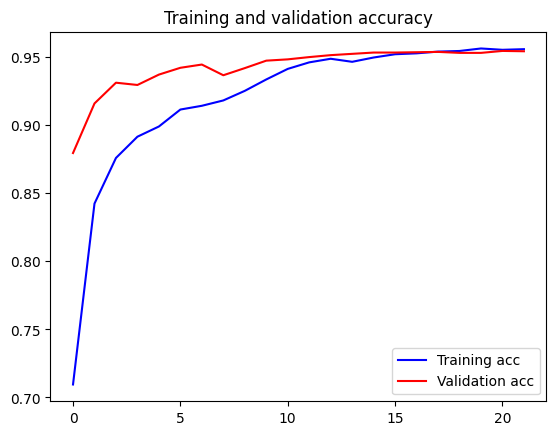

<Figure size 640x480 with 0 Axes>

In [22]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

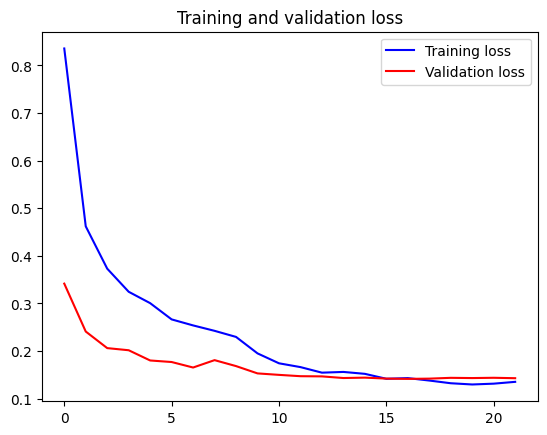

In [23]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


66/66 ━━━━━━━━━━━━━━━━━━━━ 93s 884ms/step


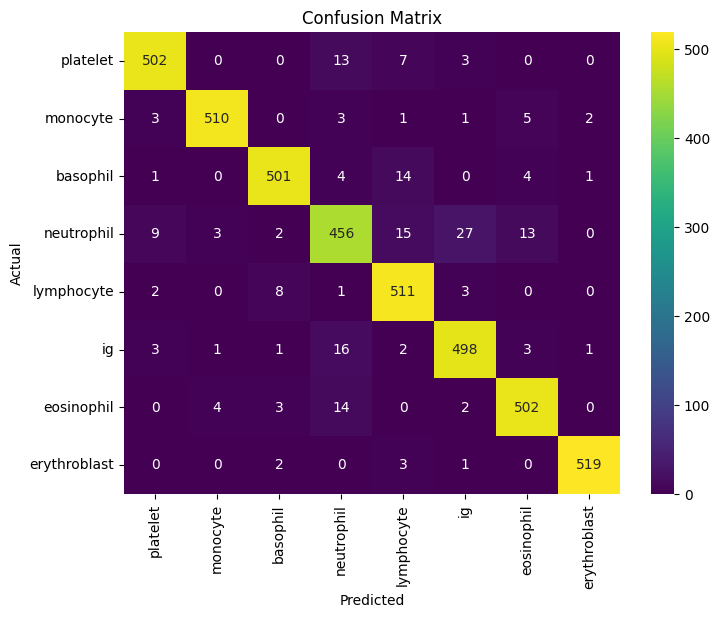

Precision: 1.0
Recall: 0.9941520467836257
F1 Score: 0.9970674486803519


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='viridis',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

cm= confusion_mtx
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]


# Calculate metrics
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 399ms/step


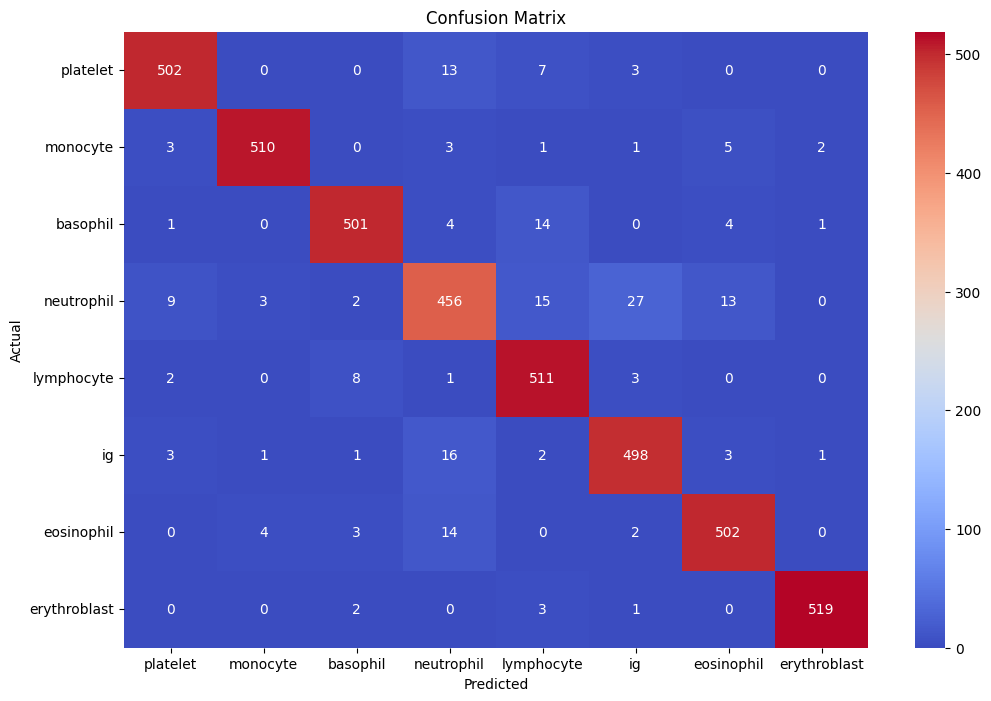

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



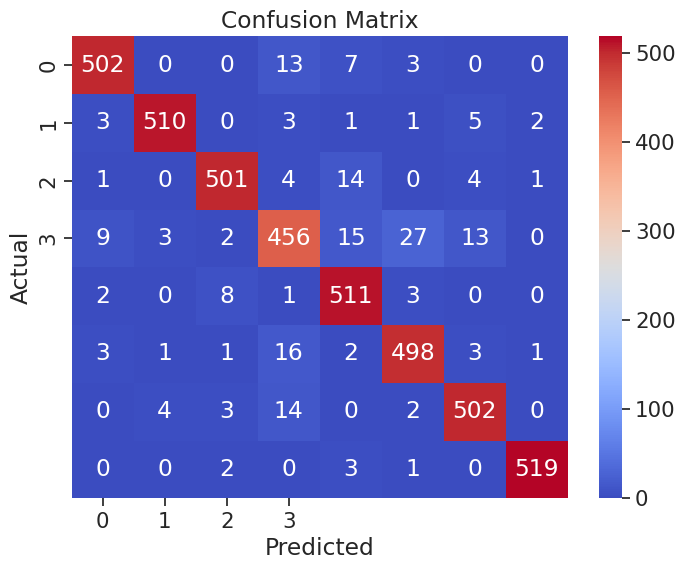

In [26]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = [0,1,2,3]
# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.4)  # Set the font scale
sns.set_style("ticks", {"font.family": "Times New Roman"})  # Set the font family to Times New Roman
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


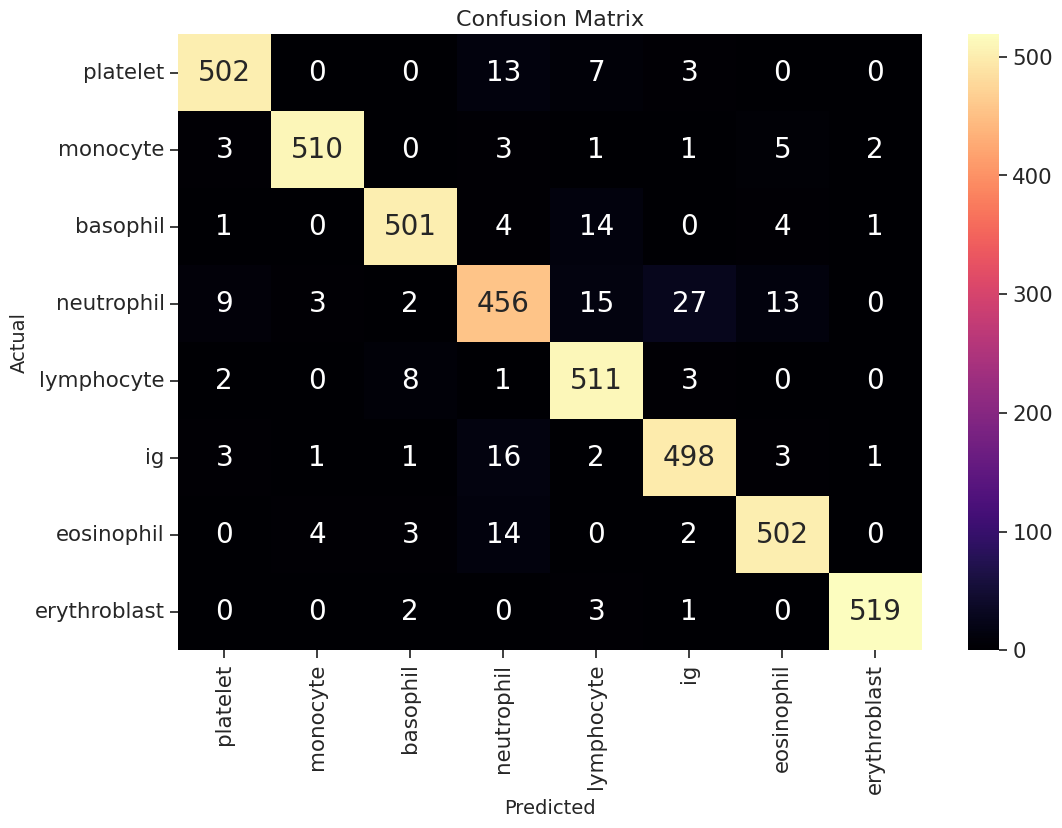

In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


In [28]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

In [29]:
# prompt: print the precision recall and f1 score

from sklearn.metrics import classification_report
# Get the classification report
report = classification_report(test_labels, predicted_labels)

# Print the report
print(report)


              precision    recall  f1-score   support

           0       0.97      0.96      0.96       525
           1       0.98      0.97      0.98       525
           2       0.97      0.95      0.96       525
           3       0.90      0.87      0.88       525
           4       0.92      0.97      0.95       525
           5       0.93      0.95      0.94       525
           6       0.95      0.96      0.95       525
           7       0.99      0.99      0.99       525

    accuracy                           0.95      4200
   macro avg       0.95      0.95      0.95      4200
weighted avg       0.95      0.95      0.95      4200



<Figure size 640x480 with 0 Axes>

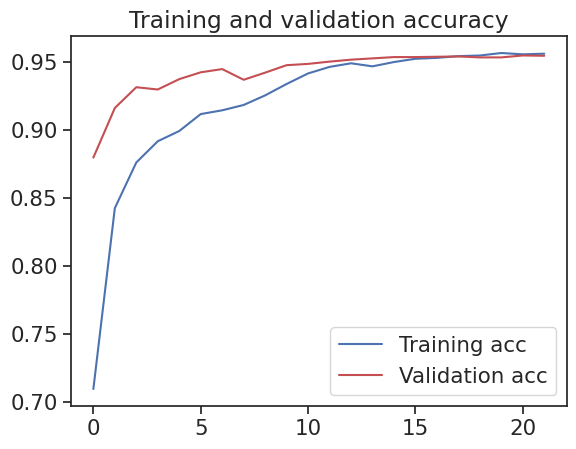

<Figure size 640x480 with 0 Axes>

In [30]:
acc = progress.history['accuracy']
val_acc = progress.history['val_accuracy']
loss = progress.history['loss']
val_loss = progress.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

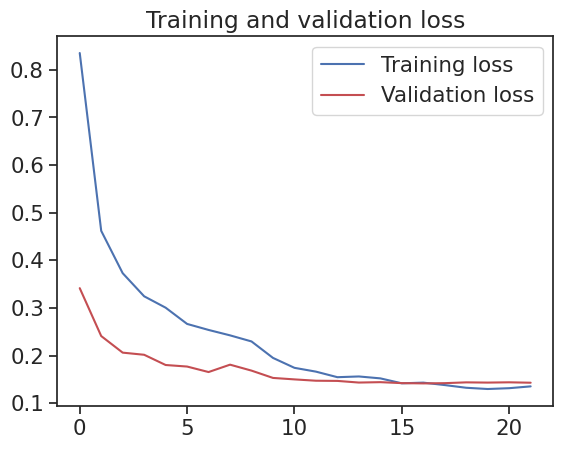

In [31]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

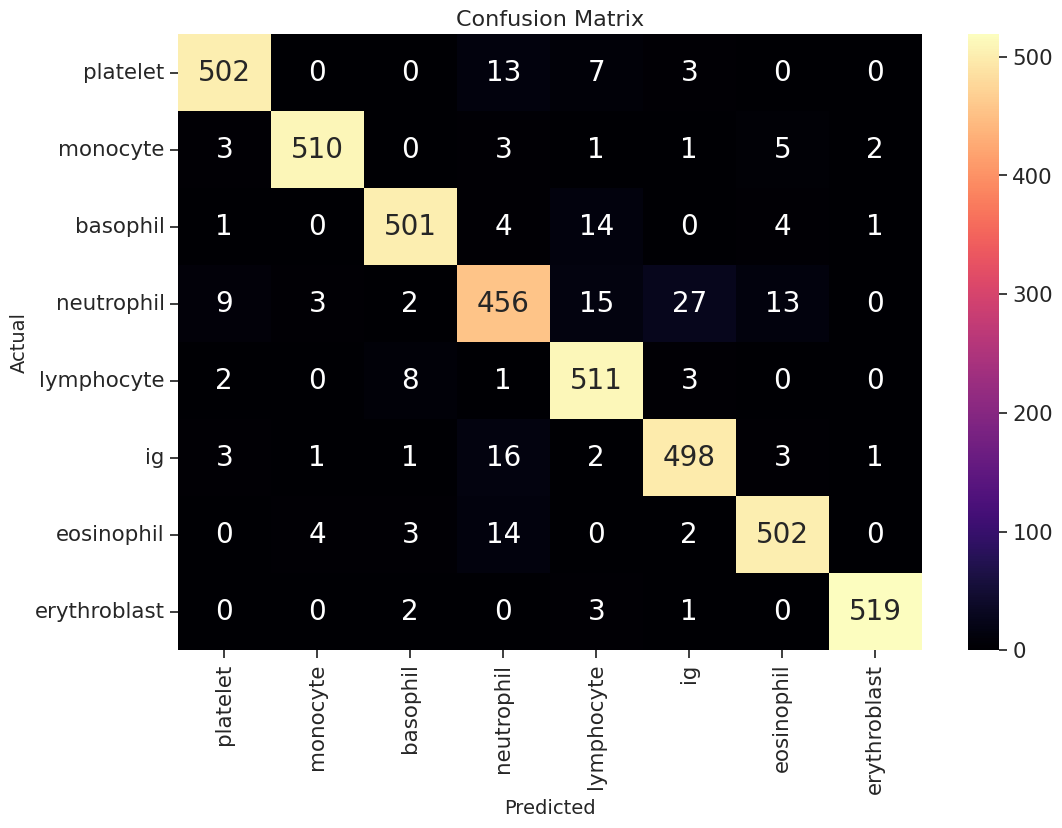

In [32]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 388ms/step


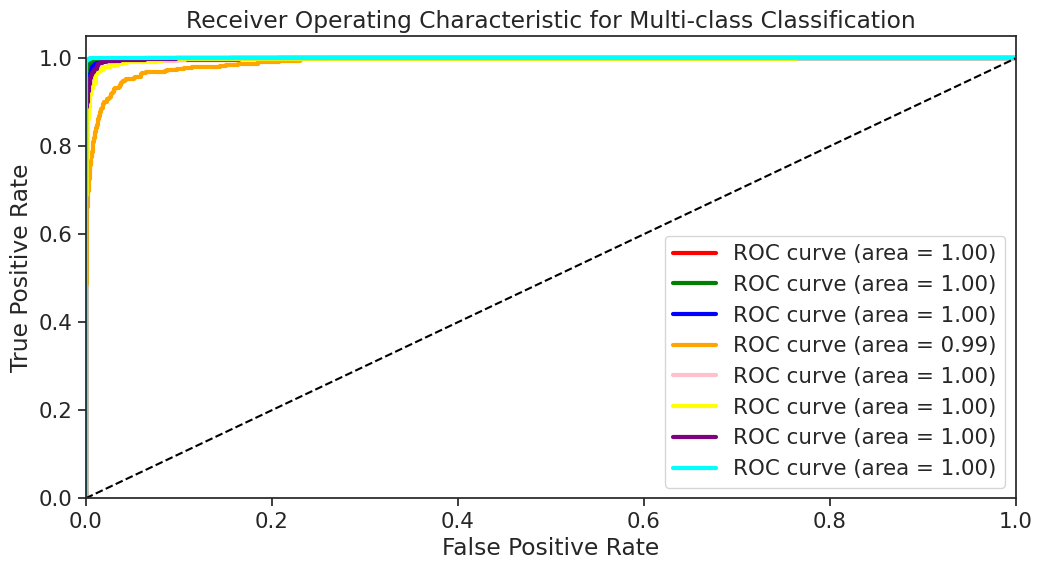

AUC scores:
Class 1: 0.9985865889212828
Class 2: 0.9994899902818271
Class 3: 0.9990141885325559
Class 4: 0.9903398769031422
Class 5: 0.9977495302883058
Class 6: 0.9963127955944284
Class 7: 0.998949400712666
Class 8: 0.999908260447036


In [33]:
# prompt: ROC Curve display for deep learning

# Get predicted probabilities for each class
predictions = model.predict(val_generator)

# Get the actual labels
test_labels = np.array(val_generator.labels)

# Binarize the test labels
test_labels_bin = keras.utils.to_categorical(test_labels)

# Calculate ROC curves and AUC for each class
fpr = {}
tpr = {}
auc_scores = {}

n_classes = 8  # Adjust this to your number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], predictions[:, i])
    auc_scores[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure(figsize=(12, 6))


lw = 3
colors = ['red', 'green', 'blue', 'orange', 'pink', 'yellow', 'purple', 'cyan']  # Adjust colors for each class

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve (area = %0.2f)' % auc_scores[i])

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-class Classification')
plt.legend(loc="lower right")
plt.show()

# Print AUC scores
print('AUC scores:')
for i, score in auc_scores.items():
    print(f'Class {i+1}: {score}')


In [34]:
# prompt: print the precision, recall and f1 score

from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities
# classes: List of class names

# Calculate precision, recall, and F1-score for each class
precision = precision_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
recall = recall_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
f1 = f1_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))

# Print the results
for i, cls in enumerate(classes):
    print(f"Class {cls}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1-score: {f1[i]:.4f}")
    print()


66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 402ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 25s 384ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 399ms/step
Class platelet:
Precision: 0.9654
Recall: 0.9562
F1-score: 0.9608

Class monocyte:
Precision: 0.9846
Recall: 0.9714
F1-score: 0.9779

Class basophil:
Precision: 0.9691
Recall: 0.9543
F1-score: 0.9616

Class neutrophil:
Precision: 0.8994
Recall: 0.8686
F1-score: 0.8837

Class lymphocyte:
Precision: 0.9241
Recall: 0.9733
F1-score: 0.9481

Class ig:
Precision: 0.9308
Recall: 0.9486
F1-score: 0.9396

Class eosinophil:
Precision: 0.9526
Recall: 0.9562
F1-score: 0.9544

Class erythroblast:
Precision: 0.9924
Recall: 0.9886
F1-score: 0.9905



In [35]:
# prompt: print the classification report

print(classification_report(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), target_names=classes))


66/66 ━━━━━━━━━━━━━━━━━━━━ 25s 379ms/step
              precision    recall  f1-score   support

    platelet       0.97      0.96      0.96       525
    monocyte       0.98      0.97      0.98       525
    basophil       0.97      0.95      0.96       525
  neutrophil       0.90      0.87      0.88       525
  lymphocyte       0.92      0.97      0.95       525
          ig       0.93      0.95      0.94       525
  eosinophil       0.95      0.96      0.95       525
erythroblast       0.99      0.99      0.99       525

    accuracy                           0.95      4200
   macro avg       0.95      0.95      0.95      4200
weighted avg       0.95      0.95      0.95      4200



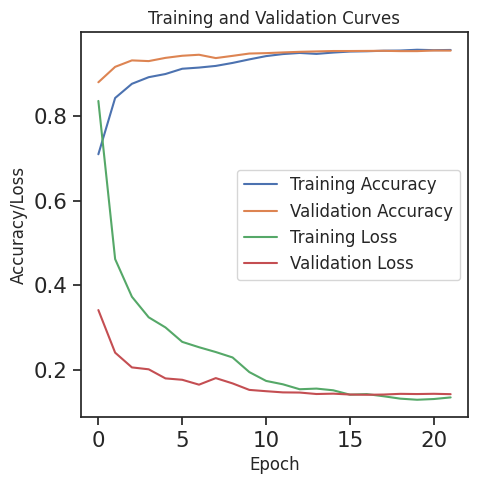

In [36]:
# prompt: plot the trainig and validation curves using seaborn

import matplotlib.pyplot as plt
# Plot training and validation curves using Seaborn
import seaborn as sns

# Create a figure and axes
fig, ax = plt.subplots(figsize=(5, 5))

# Plot training and validation accuracy
sns.lineplot(x=progress.epoch, y=acc, label='Training Accuracy', ax=ax)
sns.lineplot(x=progress.epoch, y=val_acc, label='Validation Accuracy', ax=ax)

# Plot training and validation loss
sns.lineplot(x=progress.epoch, y=loss, label='Training Loss', ax=ax)
sns.lineplot(x=progress.epoch, y=val_loss, label='Validation Loss', ax=ax)

# Set labels and title
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy/Loss', fontsize=12)
ax.set_title('Training and Validation Curves', fontsize=12)

# Add legend
plt.legend(fontsize=12)

# Display the plot
plt.show()


66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 390ms/step


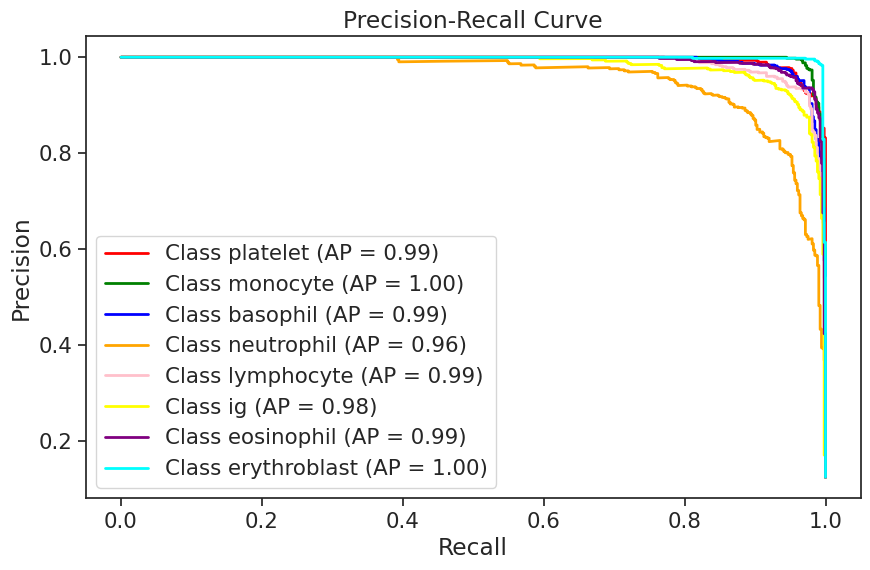

In [37]:
# prompt: create PR curve

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities
# classes: List of class names

# Get predicted probabilities for each class
y_probs = model.predict(test_generator)

# Get the true labels
y_true = test_generator.classes

# Calculate precision-recall curve and average precision for each class
precision = dict()
recall = dict()
average_precision = dict()

n_classes = len(classes)

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        (y_true == i).astype(int), y_probs[:, i]
    )
    average_precision[i] = average_precision_score(
        (y_true == i).astype(int), y_probs[:, i]
    )

# Plot the PR curve for each class
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue', 'orange', 'pink', 'yellow', 'purple', 'cyan']
for i, color in zip(range(n_classes), colors):
    plt.plot(
        recall[i],
        precision[i],
        lw=2,
        color=color,
        label=f"Class {classes[i]} (AP = {average_precision[i]:.2f})",
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step


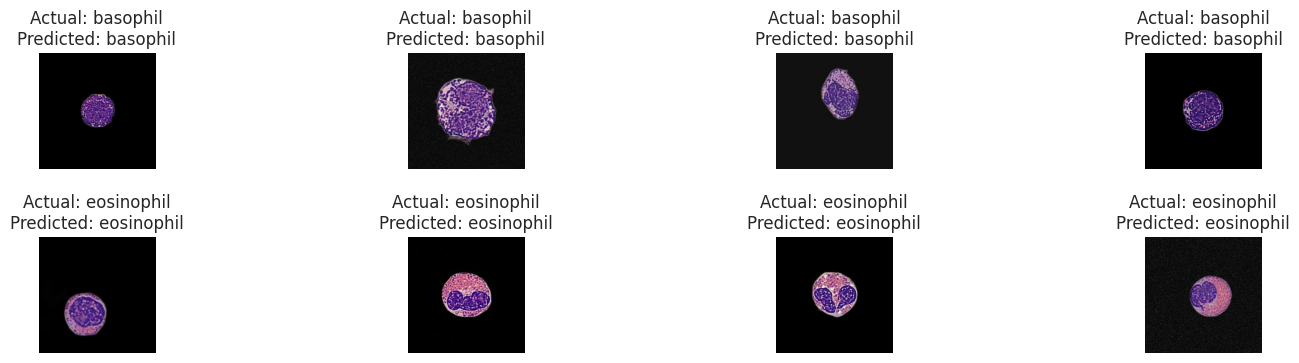

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Assuming test_generator is your test data generator and model is your trained model

# Number of classes and images per class
num_classes = 2
num_images_per_class = 4
num_images_to_display = num_classes * num_images_per_class

# Reset the test generator to the start
test_generator.reset()

# Get the class names from the test generator
class_names = list(test_generator.class_indices.keys())

# Initialize lists to store images and labels
images_to_display = []
labels_to_display = []

# Dictionary to track the number of images collected per class
collected_counts = {class_name: 0 for class_name in class_names}

# Loop to collect images from each class
while len(images_to_display) < num_images_to_display:
    images, labels = next(test_generator)
    indices = list(range(len(images)))
    random.shuffle(indices)  # Shuffle indices to select random images

    for i in indices:
        class_index = np.argmax(labels[i])  # Get the class index
        class_label = class_names[class_index]  # Get the class name

        # Check if we've already collected enough images for this class
        if collected_counts[class_label] < num_images_per_class:
            images_to_display.append(images[i])
            labels_to_display.append(labels[i])
            collected_counts[class_label] += 1

        # Stop if we've collected enough images
        if len(images_to_display) >= num_images_to_display:
            break

# Convert the lists to numpy arrays
images_to_display = np.array(images_to_display)
labels_to_display = np.array(labels_to_display)

# Make predictions for the selected images
predictions = model.predict(images_to_display)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(labels_to_display, axis=1)

# Plot the images with actual and predicted labels
plt.figure(figsize=(15, 15))  # Adjust figure size
for i in range(num_images_to_display):
    plt.subplot(8, 4, i + 1)  # 8 rows and 4 columns to accommodate 32 images
    plt.imshow(images_to_display[i])
    plt.title(f"Actual: {class_names[true_labels[i]]}\nPredicted: {class_names[predicted_labels[i]]}", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [39]:
# Reset the test generator to start
test_generator.reset()

# Generate predictions on the entire test set
predictions = model.predict(test_generator)

# Get the true labels for the entire test set
test_labels = test_generator.classes

# Convert predictions to class indices
predicted_labels = np.argmax(predictions, axis=1)

# Calculate the confusion matrix and performance metrics
cm = confusion_matrix(test_labels, predicted_labels)

# Extract true positive (TP), true negative (TN), false positive (FP), and false negative (FN) counts
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

# Calculate sensitivity (recall) and specificity
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")


66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 396ms/step
Sensitivity (Recall): 0.9942
Specificity: 1.0000


In [40]:
# prompt: give me cohen kappa score

from sklearn.metrics import cohen_kappa_score

# Assuming you have 'test_labels' (true labels) and 'predicted_labels' (predicted labels)
# from your model's evaluation.

# Example (replace with your actual data):
# test_labels = [...]  # Your true labels
# predicted_labels = [...] # Your predicted labels


kappa = cohen_kappa_score(test_labels, predicted_labels)
print(f"Cohen's Kappa Score: {kappa}")

Cohen's Kappa Score: 0.9453061224489796
